# 02 — Exploratory Data Analysis (EDA)

In [ ]:
# --- Setup ---
import sys
sys.path.append('/content/drive/MyDrive/deepfake-detection')
from google.colab import drive
drive.mount('/content/drive')
from configs.paths import *

### EDA

In [97]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

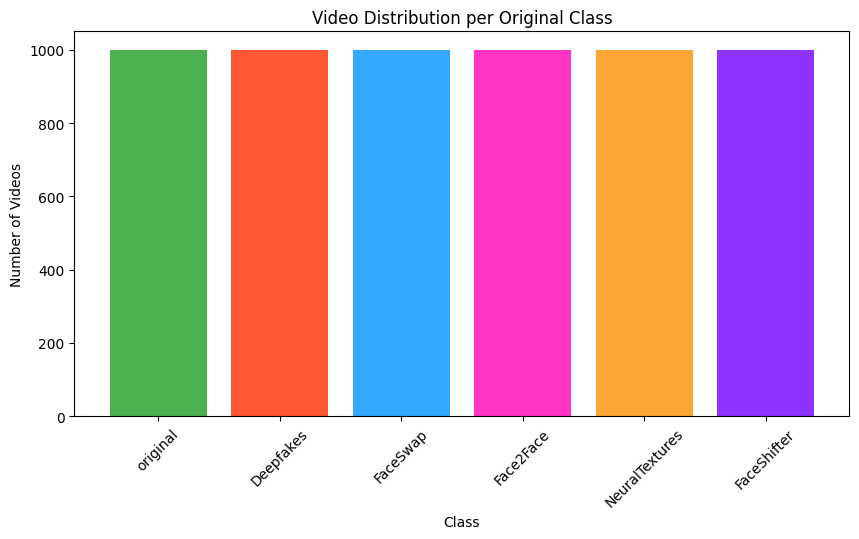

In [98]:
classes = list(class_counts.keys())
counts = list(class_counts.values())

colors = [
    "#4CAF50",  # original (green)
    "#FF5733",  # Deepfakes (red)
    "#33A8FF",  # FaceSwap (blue)
    "#FF33C4",  # Face2Face (pink)
    "#FFA533",  # NeuralTextures (orange)
    "#8D33FF"   # FaceShifter (purple)
]

plt.figure(figsize=(10,5))
plt.bar(classes, counts, color=colors)

plt.xticks(rotation=45)
plt.title("Video Distribution per Original Class")
plt.xlabel("Class")
plt.ylabel("Number of Videos")

plt.show()

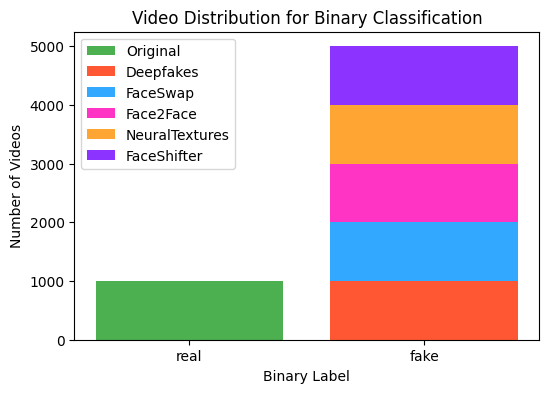

In [99]:
plt.figure(figsize=(6,4))

real = class_counts["original"]

deepfakes = class_counts["Deepfakes"]
faceswap = class_counts["FaceSwap"]
face2face = class_counts["Face2Face"]
neuraltextures = class_counts["NeuralTextures"]
faceshifter = class_counts["FaceShifter"]

# REAL BAR
plt.bar("real", real, color="#4CAF50", label="Original")

# STACKED FAKE BAR
bottom = 0

plt.bar("fake", deepfakes, bottom=bottom, color="#FF5733", label="Deepfakes")
bottom += deepfakes

plt.bar("fake", faceswap, bottom=bottom, color="#33A8FF", label="FaceSwap")
bottom += faceswap

plt.bar("fake", face2face, bottom=bottom, color="#FF33C4", label="Face2Face")
bottom += face2face

plt.bar("fake", neuraltextures, bottom=bottom, color="#FFA533", label="NeuralTextures")
bottom += neuraltextures

plt.bar("fake", faceshifter, bottom=bottom, color="#8D33FF", label="FaceShifter")

plt.title("Video Distribution for Binary Classification")
plt.xlabel("Binary Label")
plt.ylabel("Number of Videos")

plt.legend()
plt.show()

In [100]:
video_names = defaultdict(list)

for cls in VALID_CLASSES:
    folder_path = FFPP_ROOT / cls
    for vid in folder_path.rglob("*.mp4"):
        video_names[vid.name].append(cls)

shared = {k: v for k, v in video_names.items() if len(v) > 1}

print("Number of video IDs appearing in multiple classes:", len(shared))
print("\nExample shared video IDs:")
for i, (k, v) in enumerate(shared.items()):
    print(k, "->", v)
    if i == 4:
        break

Number of video IDs appearing in multiple classes: 1000

Example shared video IDs:
505_600.mp4 -> ['Deepfakes', 'FaceSwap', 'Face2Face', 'NeuralTextures', 'FaceShifter']
718_972.mp4 -> ['Deepfakes', 'FaceSwap', 'Face2Face', 'NeuralTextures', 'FaceShifter']
033_097.mp4 -> ['Deepfakes', 'FaceSwap', 'Face2Face', 'NeuralTextures', 'FaceShifter']
120_118.mp4 -> ['Deepfakes', 'FaceSwap', 'Face2Face', 'NeuralTextures', 'FaceShifter']
957_959.mp4 -> ['Deepfakes', 'FaceSwap', 'Face2Face', 'NeuralTextures', 'FaceShifter']


In [101]:
print("Important note for binary classification:")
print("Many manipulated videos share corresponding source identities/pairs across fake classes.")
print("So train/validation/test splitting must be done carefully to avoid leakage.")
print("Do not randomly split frames without considering video identity or pair relationships.")

Important note for binary classification:
Many manipulated videos share corresponding source identities/pairs across fake classes.
So train/validation/test splitting must be done carefully to avoid leakage.
Do not randomly split frames without considering video identity or pair relationships.


In [102]:
all_videos = [Path(p) for p in df_videos["video_path"].tolist()]

sample_videos = random.sample(all_videos, 10)

print("Sample video properties:\n")
for vid in sample_videos:
    cap = cv2.VideoCapture(str(vid))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    print(f"{vid.name:15s} -> {width}x{height}, {frames} frames")

Sample video properties:

459_430.mp4     -> 1920x1080, 357 frames
019_018.mp4     -> 640x480, 432 frames
171_173.mp4     -> 1280x720, 721 frames
457_398.mp4     -> 640x480, 528 frames
290_240.mp4     -> 640x480, 422 frames
931.mp4         -> 640x480, 319 frames
728_673.mp4     -> 640x480, 568 frames
103_082.mp4     -> 640x480, 316 frames
656.mp4         -> 640x480, 505 frames
248.mp4         -> 1280x720, 496 frames


In [103]:
from multiprocessing import Pool
import cv2
import multiprocessing

cores = multiprocessing.cpu_count()
print(f"Number of CPU cores: {cores}")

def get_frame_count(video_path):

    cap = cv2.VideoCapture(str(video_path))
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    if frames > 0:
      return frames
    return None

with Pool(8) as p:
    results = p.map(get_frame_count, all_videos)

frame_counts = [f for f in results if f is not None]

print("Min frames:", np.min(frame_counts))
print("Max frames:", np.max(frame_counts))
print("Mean frames:", np.mean(frame_counts))
print("Median frames:", np.median(frame_counts))

Number of CPU cores: 8
Min frames: 287
Max frames: 1814
Mean frames: 474.79816666666665
Median frames: 423.0


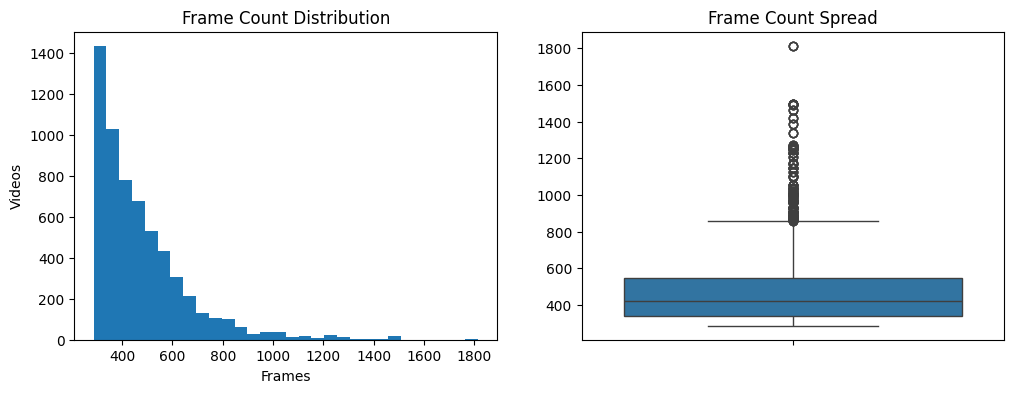

In [104]:
import seaborn as sns

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(frame_counts, bins=30)
plt.title("Frame Count Distribution")
plt.xlabel("Frames")
plt.ylabel("Videos")

plt.subplot(1,2,2)
sns.boxplot(y=frame_counts)
plt.title("Frame Count Spread")

plt.show()

Average frame count per original class:
{'original': 495.51, 'Deepfakes': 476.38, 'FaceSwap': 402.69, 'Face2Face': 483.02, 'NeuralTextures': 422.01, 'FaceShifter': 486.84}


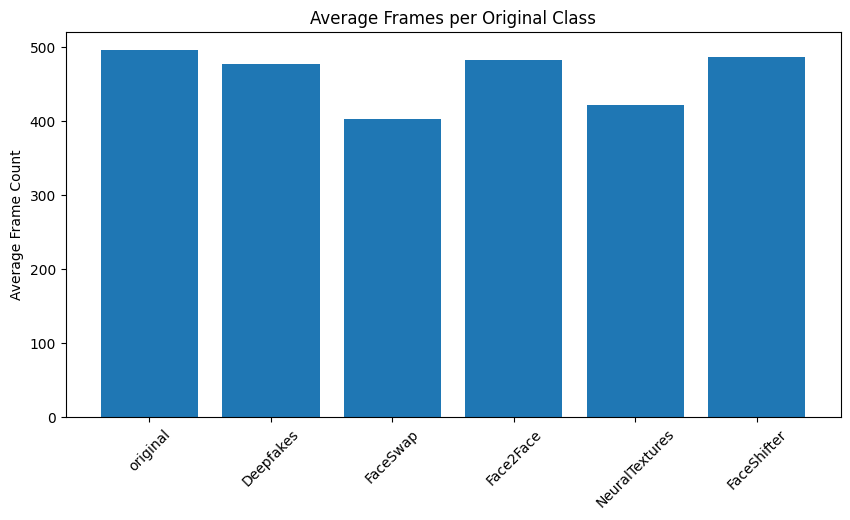

In [105]:
class_frame_stats = {}

for cls in VALID_CLASSES:
    folder_path = FFPP_ROOT / cls
    videos = list(folder_path.rglob("*.mp4"))
    sampled_videos = random.sample(videos, min(100, len(videos)))

    cls_frames = []
    for vid in sampled_videos:
        cap = cv2.VideoCapture(str(vid))
        cls_frames.append(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
        cap.release()

    class_frame_stats[cls] = np.mean(cls_frames)

print("Average frame count per original class:")
print({k: round(v, 2) for k, v in class_frame_stats.items()})

plt.figure(figsize=(10, 5))
plt.bar(class_frame_stats.keys(), class_frame_stats.values())
plt.xticks(rotation=45)
plt.title("Average Frames per Original Class")
plt.ylabel("Average Frame Count")
plt.show()

Sample video: 684_717.mp4
Total frames in video: 497
Sampled frame indices: [  0  33  66  99 132 165 198 231 264 297 330 363 396 429 462 496]


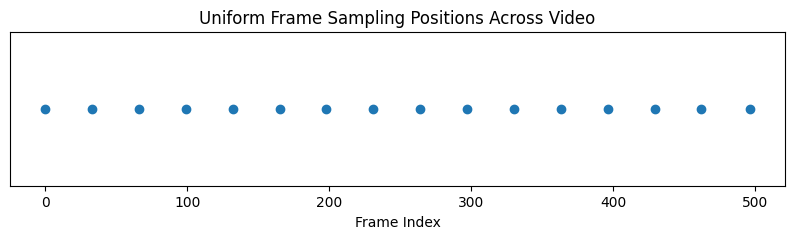

In [106]:
NUM_FRAMES = 16

sample_video = random.choice(all_videos)

cap = cv2.VideoCapture(str(sample_video))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

indices = np.linspace(0, total_frames - 1, NUM_FRAMES).astype(int)

print("Sample video:", sample_video.name)
print("Total frames in video:", total_frames)
print("Sampled frame indices:", indices)

plt.figure(figsize=(10, 2))
plt.scatter(indices, [1] * len(indices))
plt.title("Uniform Frame Sampling Positions Across Video")
plt.xlabel("Frame Index")
plt.yticks([])
plt.show()

In [107]:
resolutions = []

for vid in random.sample(all_videos, min(500, len(all_videos))):
    cap = cv2.VideoCapture(str(vid))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    resolutions.append((width, height))

resolution_counts = Counter(resolutions)

print("Resolution counts:")
for res, count in resolution_counts.items():
    print(res, ":", count)

Resolution counts:
(640, 480) : 137
(1280, 720) : 169
(832, 480) : 14
(1920, 1080) : 66
(854, 480) : 27
(600, 480) : 16
(720, 480) : 10
(654, 480) : 10
(704, 480) : 7
(656, 480) : 19
(848, 480) : 1
(576, 480) : 7
(960, 720) : 6
(1248, 720) : 1
(256, 480) : 2
(800, 480) : 3
(598, 480) : 2
(978, 720) : 1
(642, 480) : 1
(602, 480) : 1


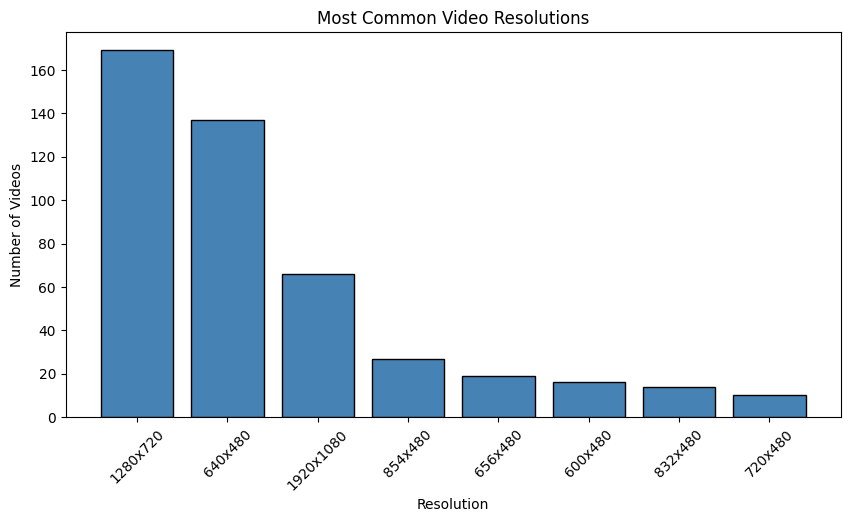

In [108]:
from collections import Counter

top_resolutions = Counter(resolutions).most_common(8)

labels = [f"{w}x{h}" for (w,h),_ in top_resolutions]
values = [v for _,v in top_resolutions]

plt.figure(figsize=(10,5))

plt.bar(labels, values, color="steelblue", edgecolor="black")

plt.title("Most Common Video Resolutions")
plt.xlabel("Resolution")
plt.ylabel("Number of Videos")

plt.xticks(rotation=45)

plt.show()

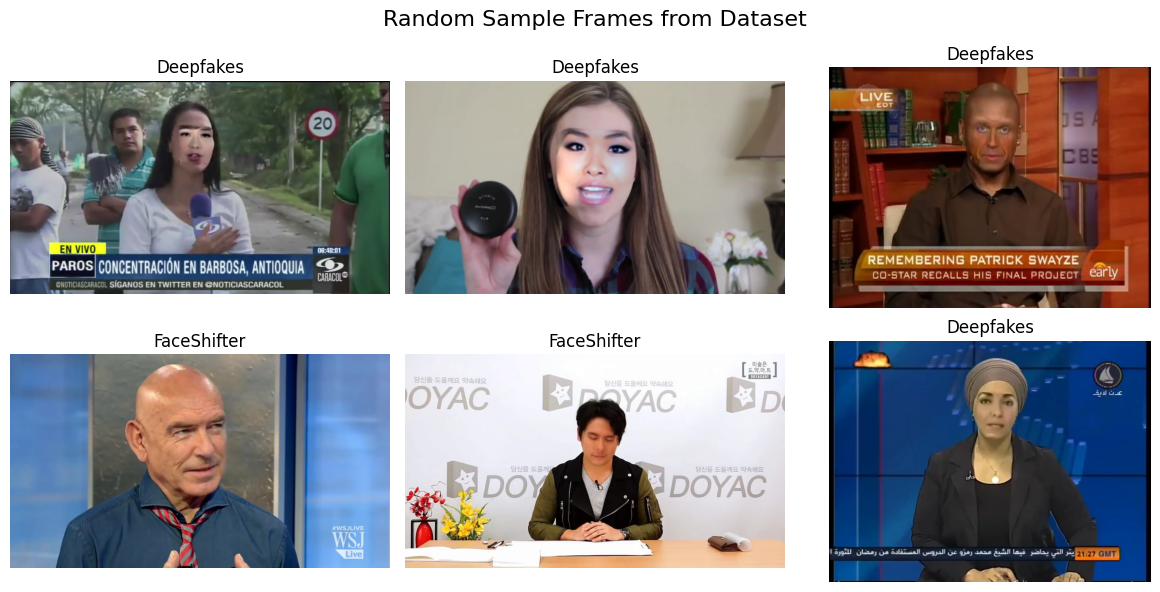

In [109]:
sample_videos = random.sample(all_videos, 6)

plt.figure(figsize=(12, 6))

for i, vid in enumerate(sample_videos):
    cap = cv2.VideoCapture(str(vid))
    ret, frame = cap.read()
    cap.release()

    if not ret:
        continue

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(frame)
    plt.title(vid.parent.name)
    plt.axis("off")

plt.suptitle("Random Sample Frames from Dataset", fontsize=16)
plt.tight_layout()
plt.show()

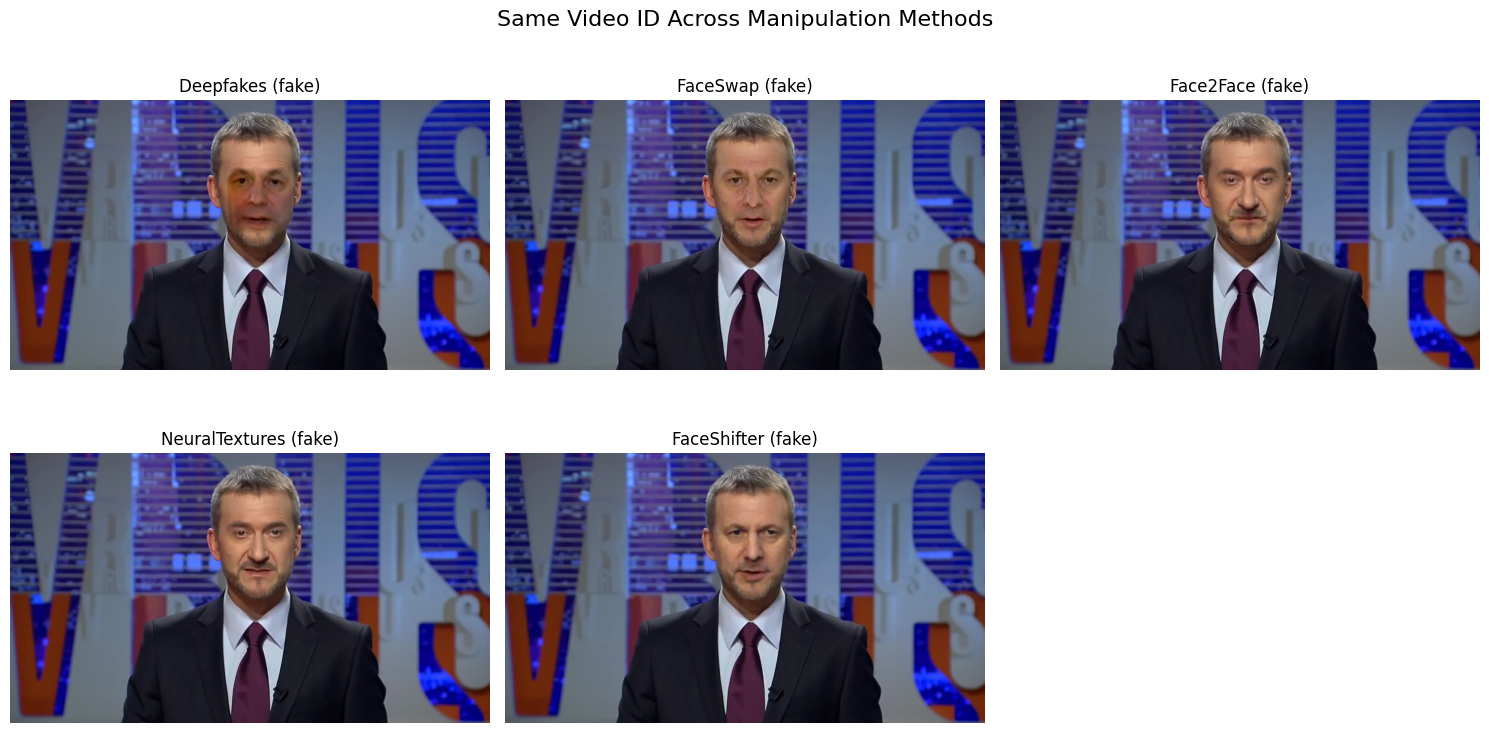

In [110]:
video_id = "594_530.mp4"

methods = [
    "original",
    "Deepfakes",
    "FaceSwap",
    "Face2Face",
    "NeuralTextures",
    "FaceShifter"
]

valid_methods = [m for m in methods if (FFPP_ROOT / m / video_id).exists()]

plt.figure(figsize=(15, 8))

for i, method in enumerate(valid_methods):
    video_path = FFPP_ROOT / method / video_id

    cap = cv2.VideoCapture(str(video_path))
    ret, frame = cap.read()
    cap.release()

    if not ret:
        continue

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(frame)
    plt.title(f"{method} ({'real' if method == 'original' else 'fake'})")
    plt.axis("off")

plt.suptitle("Same Video ID Across Manipulation Methods", fontsize=16)
plt.tight_layout()
plt.show()

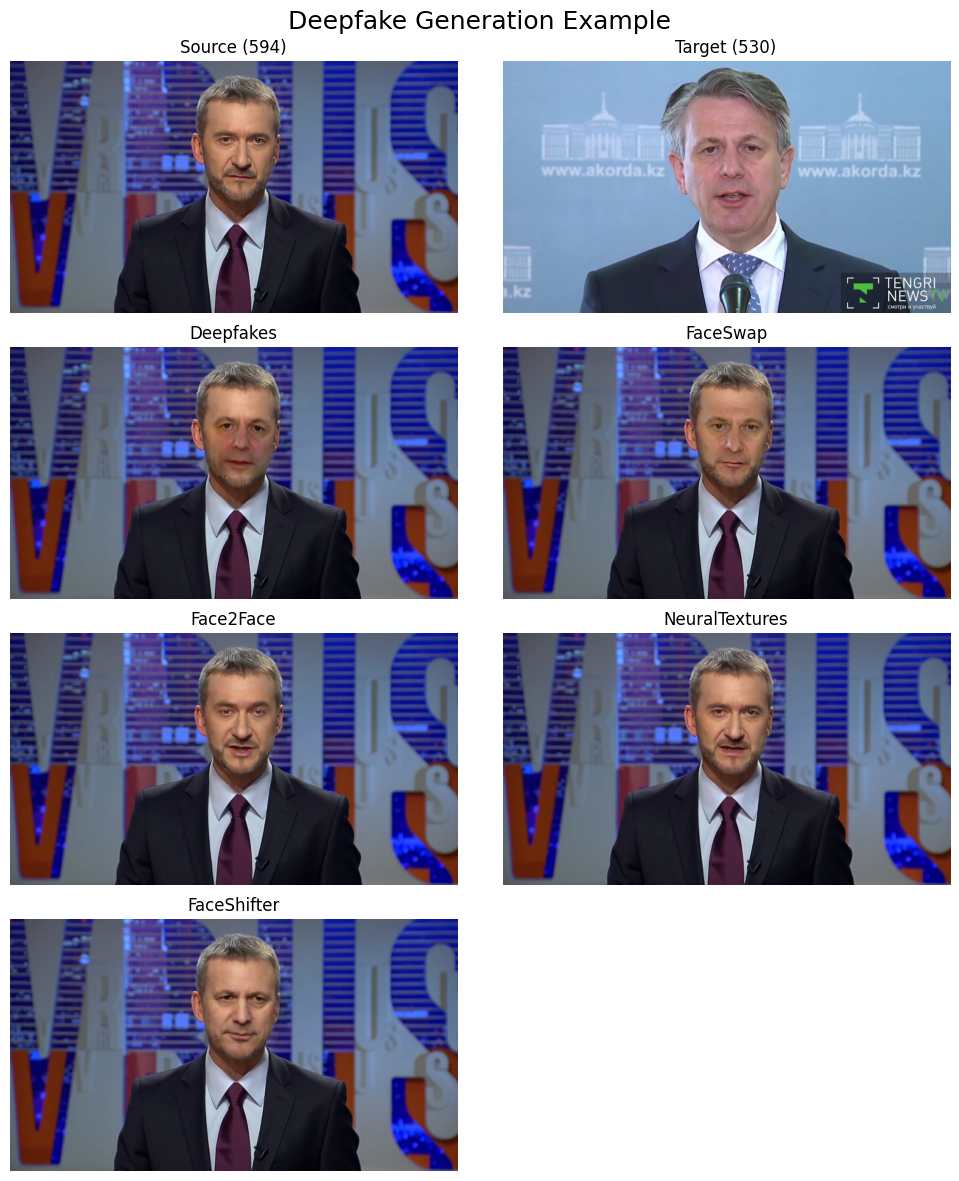

In [111]:
pair_id = "594_530.mp4"

source_id = pair_id.split("_")[0] + ".mp4"
target_id = pair_id.split("_")[1].replace(".mp4", "") + ".mp4"

def get_middle_frame(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)

    ret, frame = cap.read()
    cap.release()

    if not ret:
        return None

    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

source_path = FFPP_ROOT / "original" / source_id
target_path = FFPP_ROOT / "original" / target_id

frames = []
titles = []

source_frame = get_middle_frame(source_path)
if source_frame is not None:
    frames.append(source_frame)
    titles.append(f"Source ({source_id.replace('.mp4', '')})")

target_frame = get_middle_frame(target_path)
if target_frame is not None:
    frames.append(target_frame)
    titles.append(f"Target ({target_id.replace('.mp4', '')})")

for method in FAKE_CLASSES:
    video_path = FFPP_ROOT / method / pair_id
    frame = get_middle_frame(video_path)

    if frame is not None:
        frames.append(frame)
        titles.append(method)

cols = 2
rows = (len(frames) + cols - 1) // cols

plt.figure(figsize=(10, 12))
for i, (frame, title) in enumerate(zip(frames, titles)):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(frame)
    plt.title(title)
    plt.axis("off")

plt.suptitle("Deepfake Generation Example", fontsize=18)
plt.tight_layout()
plt.show()

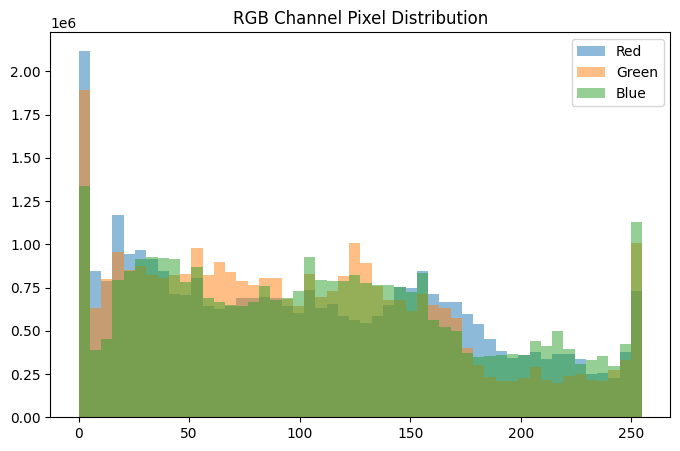

Red mean   : 103.83
Green mean : 100.77
Blue mean  : 111.68


In [112]:
r_vals, g_vals, b_vals = [], [], []

for vid in random.sample(all_videos, min(50, len(all_videos))):
    cap = cv2.VideoCapture(str(vid))
    ret, frame = cap.read()
    cap.release()

    if ret:
        r_vals.extend(frame[:, :, 2].flatten())
        g_vals.extend(frame[:, :, 1].flatten())
        b_vals.extend(frame[:, :, 0].flatten())

plt.figure(figsize=(8, 5))
plt.hist(r_vals, bins=50, alpha=0.5, label='Red')
plt.hist(g_vals, bins=50, alpha=0.5, label='Green')
plt.hist(b_vals, bins=50, alpha=0.5, label='Blue')
plt.legend()
plt.title("RGB Channel Pixel Distribution")
plt.show()

print(f"Red mean   : {np.mean(r_vals):.2f}")
print(f"Green mean : {np.mean(g_vals):.2f}")
print(f"Blue mean  : {np.mean(b_vals):.2f}")

In [113]:
total_videos = len(all_videos)
avg_frames = np.mean(frame_counts)
estimated_total_frames = int(total_videos * avg_frames)

summary = {
    "Total Videos": total_videos,
    "Original Classes": len(VALID_CLASSES),
    "Binary Classes": 2,
    "Real Videos": binary_counts["real"],
    "Fake Videos": binary_counts["fake"],
    "Average Frames per Video": round(avg_frames, 2),
    "Estimated Total Frames": estimated_total_frames
}

print("Dataset Summary:\n")
for k, v in summary.items():
    print(f"{k:25s}: {v}")

Dataset Summary:

Total Videos             : 6000
Original Classes         : 6
Binary Classes           : 2
Real Videos              : 1000
Fake Videos              : 5000
Average Frames per Video : 474.8
Estimated Total Frames   : 2848789
